# 02 EDA — Women's

Exploratory data analysis of women's basketball data to inform feature engineering and modeling decisions.

**Key questions:**
1. How predictive are seeds? What are upset rates by seed matchup?
2. Which team-season stats separate tournament winners from losers?
3. How have scoring and pace trends changed over time?
4. What features correlate most with tournament success?

**Note:** Women's data differs from men's in several important ways:
- Compact results start in 1998 (vs 1985 for men's)
- Detailed box score stats start in 2010 (vs 2003 for men's)
- No Massey Ordinals available for women's
- No coaches data available for women's
- Women's tournament historically has fewer upsets than men's
- TeamIDs are 3000+ (vs 1000-1999 for men's)

**Inputs** (from S3 `01_data_joining/womens/`):
- `regular_season_games.parquet`
- `tourney_games.parquet`
- `team_season_stats.parquet`
- `tourney_seeds.parquet`
- `team_metadata.parquet`

**Outputs**: Plots saved to `02_eda/output/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

#### Functions

In [2]:
def read_parquet(filename):
    """Read parquet from S3 if available, otherwise fall back to local."""
    try:
        return pd.read_parquet(f"{INPUT_PREFIX}{filename}")
    except Exception:
        return pd.read_parquet(f"{LOCAL_INPUT}{filename}")

def save_plot(fig, name):
    """Save plot to local output directory."""
    fig.savefig(f"{LOCAL_OUTPUT}{name}.png", bbox_inches='tight', dpi=150)
    print(f"Saved: {LOCAL_OUTPUT}{name}.png")

#### Constants

In [3]:
BUCKET = "march-machine-learning-mania-2026"
GENDER = "womens"
STAGE = "02_eda"
INPUT_PREFIX = f"s3://{BUCKET}/01_data_joining/{GENDER}/"
OUTPUT_PREFIX = f"s3://{BUCKET}/{STAGE}/{GENDER}/"

LOCAL_INPUT = "../01_data_joining/output/"
LOCAL_OUTPUT = "output/"

#### Make output directory

In [4]:
os.makedirs(LOCAL_OUTPUT, exist_ok=True)

## 1. Load Data

Women's data has no Massey Ordinals and no coaches data. Compact results begin in 1998; detailed box scores begin in 2010.

In [5]:
reg_games = read_parquet("regular_season_games.parquet")
tourney_games = read_parquet("tourney_games.parquet")
team_stats = read_parquet("team_season_stats.parquet")
seeds = read_parquet("tourney_seeds.parquet")
team_meta = read_parquet("team_metadata.parquet")

print(f"Regular season games: {reg_games.shape}")
print(f"Tournament games: {tourney_games.shape}")
print(f"Team-season stats: {team_stats.shape}")
print(f"Seeds: {seeds.shape}")
print(f"Team metadata: {team_meta.shape}")

print(f"\nSeason range: {reg_games['Season'].min()} - {reg_games['Season'].max()}")
print(f"TeamID range: {reg_games['WTeamID'].min()} - {reg_games['WTeamID'].max()}")

Regular season games: (142093, 34)
Tournament games: (1717, 34)
Team-season stats: (9851, 49)
Seeds: (1744, 6)
Team metadata: (9853, 6)

Season range: 1998 - 2026
TeamID range: 3101 - 3481


## 2. Seed Analysis

Seeds are the single most universally used feature. The women's tournament historically has fewer upsets than the men's — higher seeds dominate more consistently. Understanding seed matchup win rates and upset frequencies is critical.

In [6]:
# Join seeds to tournament games
tourney_with_seeds = tourney_games.merge(
    seeds[['Season', 'TeamID', 'SeedNum']],
    left_on=['Season', 'WTeamID'],
    right_on=['Season', 'TeamID'],
    how='left'
).rename(columns={'SeedNum': 'WSeed'}).drop(columns=['TeamID'])

tourney_with_seeds = tourney_with_seeds.merge(
    seeds[['Season', 'TeamID', 'SeedNum']],
    left_on=['Season', 'LTeamID'],
    right_on=['Season', 'TeamID'],
    how='left'
).rename(columns={'SeedNum': 'LSeed'}).drop(columns=['TeamID'])

tourney_with_seeds['SeedDiff'] = tourney_with_seeds['WSeed'] - tourney_with_seeds['LSeed']
tourney_with_seeds['Upset'] = (tourney_with_seeds['WSeed'] > tourney_with_seeds['LSeed']).astype(int)

print(f"Tournament games with seeds: {tourney_with_seeds.dropna(subset=['WSeed', 'LSeed']).shape[0]}")
print(f"Overall upset rate: {tourney_with_seeds['Upset'].mean():.3f}")
print(f"\nNote: Women's upset rate is typically lower than men's (~0.27)")

Tournament games with seeds: 1717
Overall upset rate: 0.211

Note: Women's upset rate is typically lower than men's (~0.27)


Saved: output/womens_seed_win_rate.png


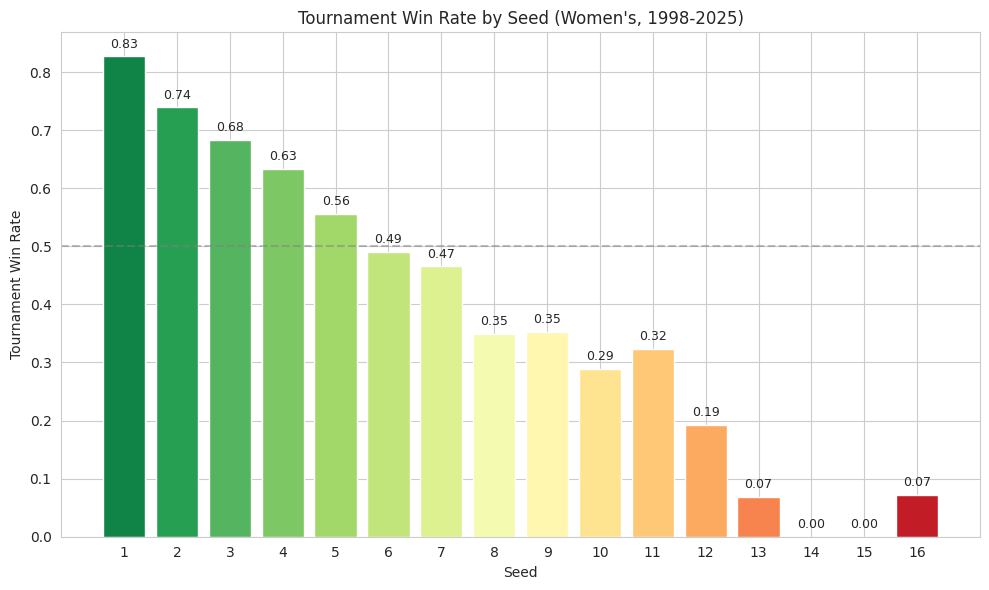

In [7]:
# Win rate by seed — how often does each seed win its tournament games?
# Build team-centric view of tourney games with seeds
w_rows = tourney_with_seeds[['Season', 'WTeamID', 'WSeed']].rename(
    columns={'WTeamID': 'TeamID', 'WSeed': 'SeedNum'})
w_rows['Win'] = 1

l_rows = tourney_with_seeds[['Season', 'LTeamID', 'LSeed']].rename(
    columns={'LTeamID': 'TeamID', 'LSeed': 'SeedNum'})
l_rows['Win'] = 0

seed_games = pd.concat([w_rows, l_rows], ignore_index=True).dropna(subset=['SeedNum'])
seed_games['SeedNum'] = seed_games['SeedNum'].astype(int)

seed_winrate = seed_games.groupby('SeedNum')['Win'].agg(['mean', 'count']).reset_index()
seed_winrate.columns = ['Seed', 'WinRate', 'Games']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(seed_winrate['Seed'], seed_winrate['WinRate'], color=sns.color_palette('RdYlGn_r', 16))
ax.set_xlabel('Seed')
ax.set_ylabel('Tournament Win Rate')
ax.set_title('Tournament Win Rate by Seed (Women\'s, 1998-2025)')
ax.set_xticks(range(1, 17))
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
for bar, (_, row) in zip(bars, seed_winrate.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{row["WinRate"]:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
save_plot(fig, 'womens_seed_win_rate')
plt.show()

In [8]:
# Seed matchup win probability matrix
# For each (higher seed vs lower seed) matchup, what fraction does the higher seed win?
matchups = tourney_with_seeds.dropna(subset=['WSeed', 'LSeed']).copy()
matchups['HighSeed'] = matchups[['WSeed', 'LSeed']].min(axis=1).astype(int)
matchups['LowSeed'] = matchups[['WSeed', 'LSeed']].max(axis=1).astype(int)
matchups['HighSeedWon'] = (matchups['WSeed'] == matchups['HighSeed']).astype(int)

matchup_matrix = matchups.groupby(['HighSeed', 'LowSeed'])['HighSeedWon'].agg(['mean', 'count']).reset_index()
matchup_matrix.columns = ['HighSeed', 'LowSeed', 'HighSeedWinRate', 'Count']

# Show common first-round matchups
first_round = matchup_matrix[matchup_matrix['HighSeed'] + matchup_matrix['LowSeed'] == 17]
first_round = first_round.sort_values('HighSeed')
print("First Round Matchup Win Rates (Higher Seed):")
for _, row in first_round.iterrows():
    print(f"  #{int(row['HighSeed'])} vs #{int(row['LowSeed'])}: "
          f"{row['HighSeedWinRate']:.3f} ({int(row['Count'])} games)")

First Round Matchup Win Rates (Higher Seed):
  #1 vs #16: 0.991 (108 games)
  #2 vs #15: 1.000 (108 games)
  #3 vs #14: 1.000 (108 games)
  #4 vs #13: 0.944 (108 games)
  #5 vs #12: 0.796 (108 games)
  #6 vs #11: 0.676 (108 games)
  #7 vs #10: 0.657 (108 games)
  #8 vs #9: 0.519 (108 games)


Saved: output/womens_seed_matchup_heatmap.png


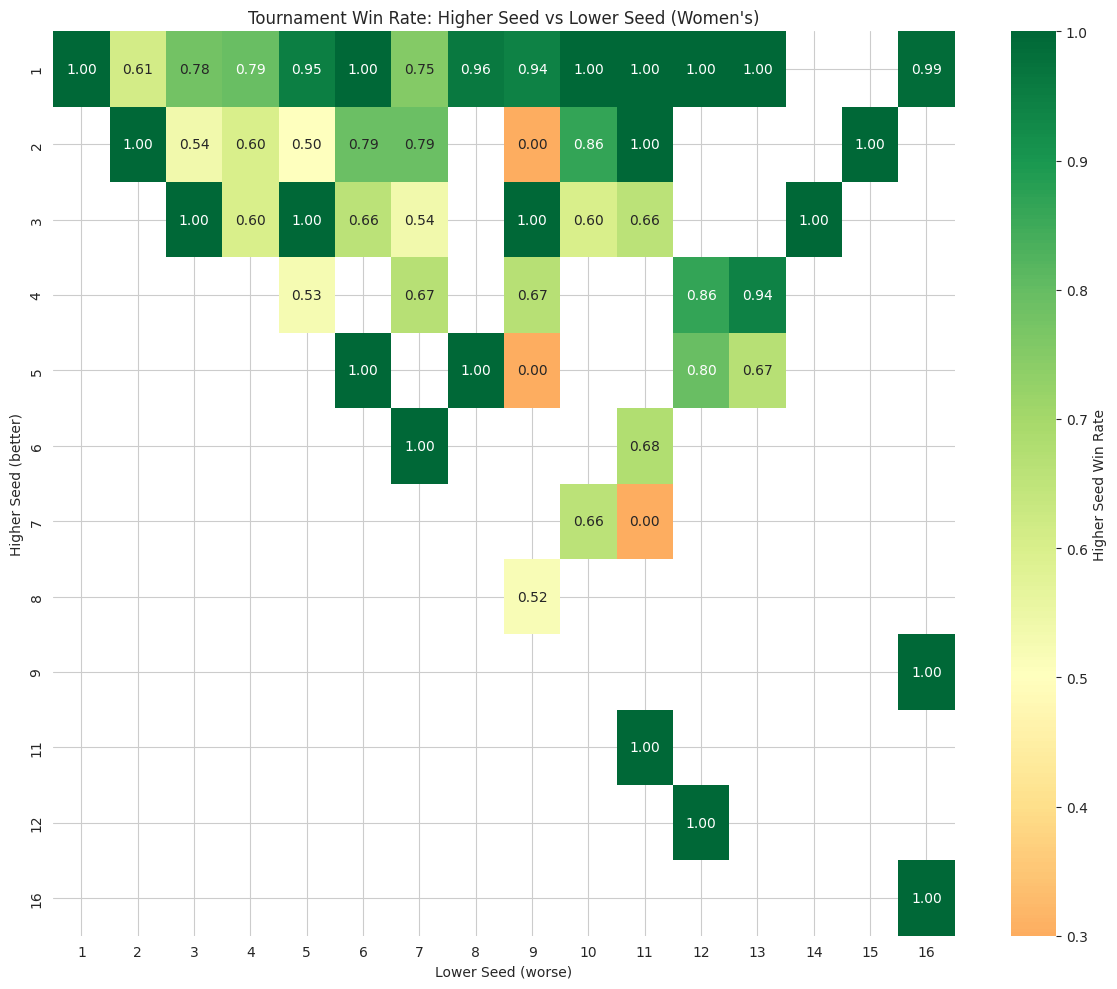

In [9]:
# Seed matchup heatmap
pivot = matchup_matrix.pivot_table(
    index='HighSeed', columns='LowSeed', values='HighSeedWinRate'
)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5,
            vmin=0.3, vmax=1.0, ax=ax, cbar_kws={'label': 'Higher Seed Win Rate'})
ax.set_title('Tournament Win Rate: Higher Seed vs Lower Seed (Women\'s)')
ax.set_xlabel('Lower Seed (worse)')
ax.set_ylabel('Higher Seed (better)')
plt.tight_layout()
save_plot(fig, 'womens_seed_matchup_heatmap')
plt.show()

Saved: output/womens_upset_rate_over_time.png


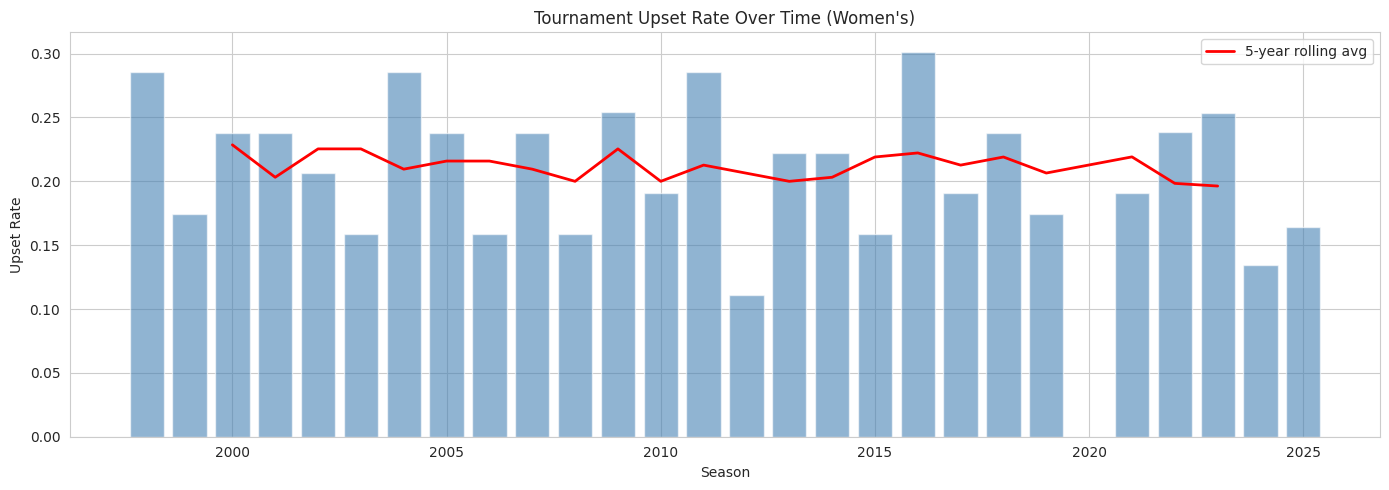

In [10]:
# Upset rate over time — is the women's tournament getting more or less predictable?
upset_by_year = tourney_with_seeds.groupby('Season')['Upset'].mean().reset_index()
upset_by_year.columns = ['Season', 'UpsetRate']

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(upset_by_year['Season'], upset_by_year['UpsetRate'], alpha=0.6, color='steelblue')
ax.plot(upset_by_year['Season'], upset_by_year['UpsetRate'].rolling(5, center=True).mean(),
        color='red', linewidth=2, label='5-year rolling avg')
ax.set_xlabel('Season')
ax.set_ylabel('Upset Rate')
ax.set_title('Tournament Upset Rate Over Time (Women\'s)')
ax.legend()
plt.tight_layout()
save_plot(fig, 'womens_upset_rate_over_time')
plt.show()

## 3. Team Stats — Tournament Teams vs Non-Tournament Teams

What regular season stats distinguish teams that make the tournament from those that don't? Detailed stats are available from 2010+ for women's (vs 2003+ for men's).

In [11]:
# Mark which team-seasons made the tournament
tourney_teams = seeds[['Season', 'TeamID']].drop_duplicates()
tourney_teams['InTourney'] = 1

stats_with_tourney = team_stats.merge(tourney_teams, on=['Season', 'TeamID'], how='left')
stats_with_tourney['InTourney'] = stats_with_tourney['InTourney'].fillna(0).astype(int)

# Focus on seasons with detailed stats (2010+ for women's)
stats_detail = stats_with_tourney[stats_with_tourney.Season >= 2010].copy()

print(f"Team-seasons 2010+: {len(stats_detail)}")
print(f"Tournament teams: {stats_detail['InTourney'].sum()}")
print(f"Non-tournament teams: {(stats_detail['InTourney'] == 0).sum()}")

Team-seasons 2010+: 5966
Tournament teams: 976
Non-tournament teams: 4990


In [12]:
# Compare key stats between tournament and non-tournament teams
compare_cols = ['WinPct', 'AvgPointDiff', 'OffEff', 'DefEff', 'NetEff',
                'FGPct', 'FG3Pct', 'FTPct', 'AvgTO', 'AvgStl', 'AvgBlk',
                'AvgOR', 'AvgDR', 'AvgAst']

# Only use columns that exist in the data
compare_cols = [c for c in compare_cols if c in stats_detail.columns]

comparison = stats_detail.groupby('InTourney')[compare_cols].mean().T
comparison.columns = ['Non-Tourney', 'Tourney']
comparison['Diff'] = comparison['Tourney'] - comparison['Non-Tourney']
comparison['Diff%'] = (comparison['Diff'] / comparison['Non-Tourney'] * 100).round(1)

print("Tournament vs Non-Tournament Team Averages (Women's, 2010+):")
print(comparison.to_string())

Tournament vs Non-Tournament Team Averages (Women's, 2010+):
              Non-Tourney    Tourney       Diff  Diff%
WinPct           0.443245   0.753962   0.310716   70.1
AvgPointDiff    -2.484470  11.094274  13.578745 -546.5
OffEff           0.885886   1.000766   0.114880   13.0
DefEff           0.920201   0.846548  -0.073653   -8.0
NetEff          -0.034315   0.154218   0.188533 -549.4
FGPct            0.391947   0.432395   0.040448   10.3
FG3Pct           0.305497   0.334270   0.028773    9.4
FTPct            0.694719   0.714604   0.019886    2.9
AvgTO           16.227242  14.631833  -1.595409   -9.8
AvgStl           7.671337   8.442410   0.771074   10.1
AvgBlk           3.318411   3.846357   0.527946   15.9
AvgOR           11.365127  12.297916   0.932789    8.2
AvgDR           24.114173  25.640861   1.526688    6.3
AvgAst          12.486703  15.000655   2.513952   20.1


Saved: output/womens_tourney_vs_non_tourney_distributions.png


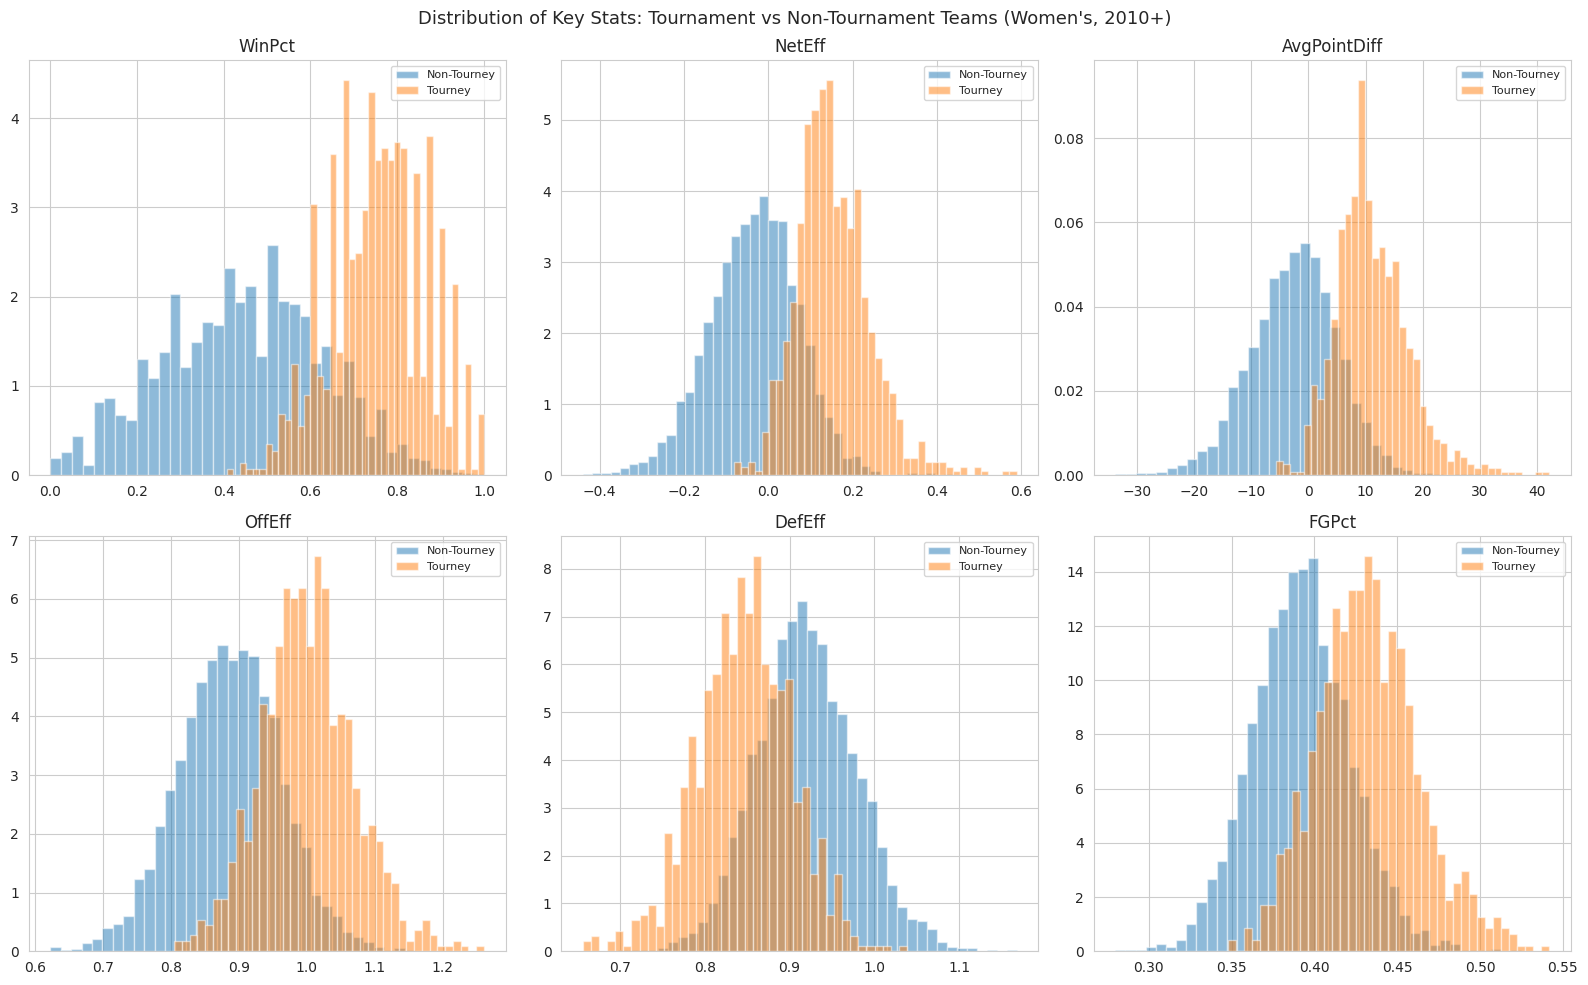

In [13]:
# Distribution plots for the most discriminating features
top_features = ['WinPct', 'NetEff', 'AvgPointDiff', 'OffEff', 'DefEff', 'FGPct']
top_features = [f for f in top_features if f in stats_detail.columns]

n_features = len(top_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
for ax, feat in zip(axes.flat, top_features):
    for label, group in stats_detail.groupby('InTourney'):
        name = 'Tourney' if label == 1 else 'Non-Tourney'
        ax.hist(group[feat].dropna(), bins=40, alpha=0.5, label=name, density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)

# Hide any extra axes
for ax in axes.flat[n_features:]:
    ax.set_visible(False)

fig.suptitle('Distribution of Key Stats: Tournament vs Non-Tournament Teams (Women\'s, 2010+)', fontsize=13)
plt.tight_layout()
save_plot(fig, 'womens_tourney_vs_non_tourney_distributions')
plt.show()

## 4. Feature Correlation with Tournament Wins

Among tournament teams, which stats correlate most with winning tournament games?

Saved: output/womens_feature_correlation_tourney_wins.png


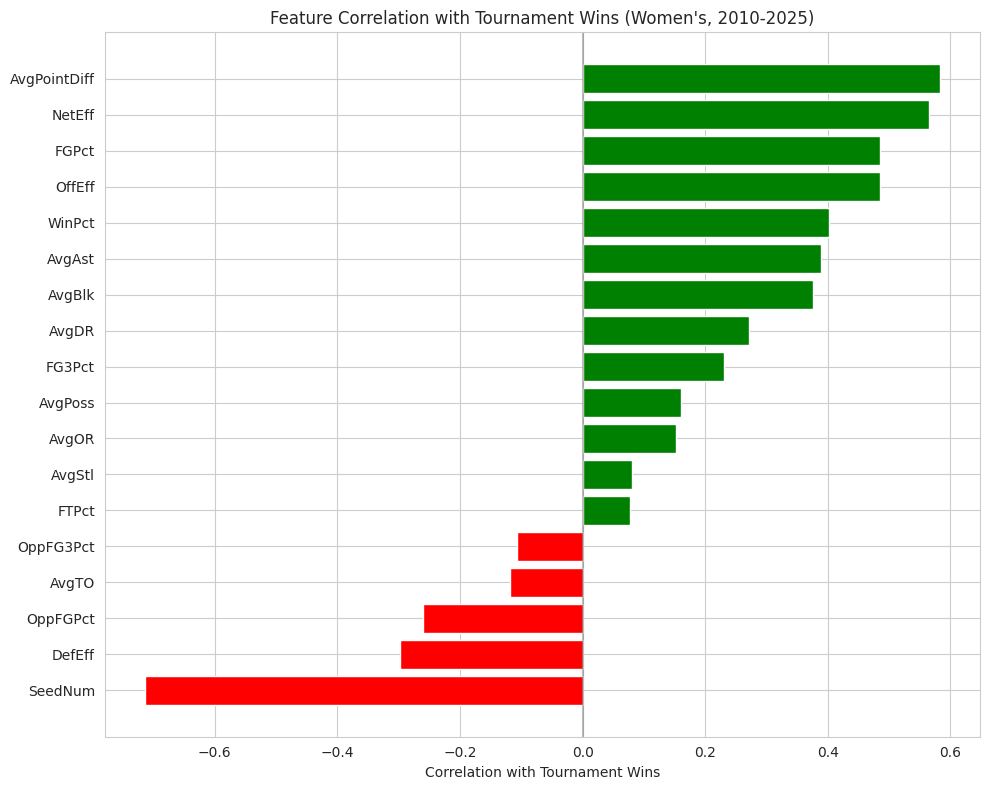


Correlation values:
  AvgPointDiff        : +0.583
  NetEff              : +0.565
  FGPct               : +0.486
  OffEff              : +0.485
  WinPct              : +0.402
  AvgAst              : +0.389
  AvgBlk              : +0.376
  AvgDR               : +0.271
  FG3Pct              : +0.230
  AvgPoss             : +0.160
  AvgOR               : +0.153
  AvgStl              : +0.080
  FTPct               : +0.077
  OppFG3Pct           : -0.106
  AvgTO               : -0.119
  OppFGPct            : -0.261
  DefEff              : -0.297
  SeedNum             : -0.715


In [14]:
# Count tournament wins per team-season
tourney_wins = tourney_games.groupby(['Season', 'WTeamID']).size().reset_index(name='TourneyWins')
tourney_wins = tourney_wins.rename(columns={'WTeamID': 'TeamID'})

# Merge with team stats (only tournament teams, 2010+)
tourney_team_stats = stats_detail[stats_detail['InTourney'] == 1].merge(
    tourney_wins, on=['Season', 'TeamID'], how='left'
)
tourney_team_stats['TourneyWins'] = tourney_team_stats['TourneyWins'].fillna(0)

# Also join seeds
tourney_team_stats = tourney_team_stats.merge(
    seeds[['Season', 'TeamID', 'SeedNum']], on=['Season', 'TeamID'], how='left'
)

# Correlation with tournament wins
corr_cols = ['SeedNum', 'WinPct', 'AvgPointDiff', 'OffEff', 'DefEff', 'NetEff',
             'FGPct', 'FG3Pct', 'FTPct', 'AvgTO', 'AvgStl', 'AvgBlk',
             'AvgOR', 'AvgDR', 'AvgAst', 'AvgPoss', 'OppFGPct', 'OppFG3Pct']

# Only use columns that exist in the data
corr_cols = [c for c in corr_cols if c in tourney_team_stats.columns]

correlations = tourney_team_stats[corr_cols + ['TourneyWins']].corr()['TourneyWins'].drop('TourneyWins')
correlations = correlations.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['green' if v > 0 else 'red' for v in correlations.values]
ax.barh(range(len(correlations)), correlations.values, color=colors)
ax.set_yticks(range(len(correlations)))
ax.set_yticklabels(correlations.index)
ax.set_xlabel('Correlation with Tournament Wins')
ax.set_title('Feature Correlation with Tournament Wins (Women\'s, 2010-2025)')
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
ax.invert_yaxis()
plt.tight_layout()
save_plot(fig, 'womens_feature_correlation_tourney_wins')
plt.show()

print("\nCorrelation values:")
for feat, corr in correlations.items():
    print(f"  {feat:20s}: {corr:+.3f}")

## 5. Scoring and Pace Trends Over Time

Saved: output/womens_scoring_and_pace_trends.png


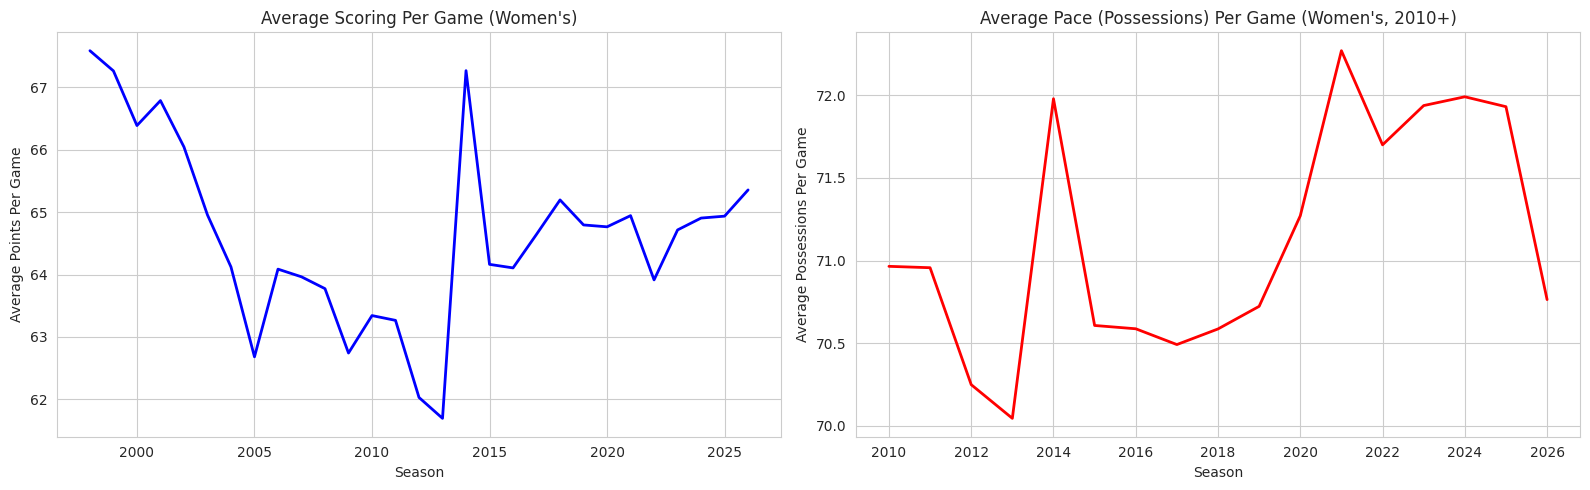

In [15]:
# Average score per season
score_cols = ['AvgScore']
if 'AvgOppScore' in team_stats.columns:
    score_cols.append('AvgOppScore')
if 'AvgPoss' in team_stats.columns:
    score_cols.append('AvgPoss')

season_avg = team_stats.groupby('Season')[score_cols].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scoring trend
axes[0].plot(season_avg['Season'], season_avg['AvgScore'], 'b-', linewidth=2)
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Average Points Per Game')
axes[0].set_title('Average Scoring Per Game (Women\'s)')

# Pace trend (possessions, 2010+ only for women's)
if 'AvgPoss' in season_avg.columns:
    pace = season_avg.dropna(subset=['AvgPoss'])
    axes[1].plot(pace['Season'], pace['AvgPoss'], 'r-', linewidth=2)
    axes[1].set_xlabel('Season')
    axes[1].set_ylabel('Average Possessions Per Game')
    axes[1].set_title('Average Pace (Possessions) Per Game (Women\'s, 2010+)')
else:
    axes[1].text(0.5, 0.5, 'AvgPoss not available', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title('Pace Data Not Available')

plt.tight_layout()
save_plot(fig, 'womens_scoring_and_pace_trends')
plt.show()

## 6. Power Conference Analysis

In [16]:
# How do power conference teams perform in the tournament?
tourney_meta = tourney_team_stats.merge(
    team_meta[['Season', 'TeamID', 'IsPowerConf', 'ConfAbbrev']],
    on=['Season', 'TeamID'],
    how='left'
)

power_perf = tourney_meta.groupby('IsPowerConf').agg(
    AvgTourneyWins=('TourneyWins', 'mean'),
    AvgSeed=('SeedNum', 'mean'),
    Count=('TeamID', 'count')
).reset_index()
power_perf['IsPowerConf'] = power_perf['IsPowerConf'].map({0: 'Mid-Major', 1: 'Power Conf'})

print("Tournament Performance by Conference Type (Women's, 2010+):")
print(power_perf.to_string(index=False))

# Win rate by conference in tournament
conf_wins = tourney_meta.groupby('ConfAbbrev').agg(
    AvgTourneyWins=('TourneyWins', 'mean'),
    TeamsInTourney=('TeamID', 'count')
).reset_index()
conf_wins = conf_wins[conf_wins.TeamsInTourney >= 10].sort_values('AvgTourneyWins', ascending=False)

print(f"\nTop conferences by avg tournament wins (min 10 appearances):")
print(conf_wins.head(15).to_string(index=False))

Tournament Performance by Conference Type (Women's, 2010+):
IsPowerConf  AvgTourneyWins   AvgSeed  Count
  Mid-Major        0.318386 12.318386    446
 Power Conf        1.545283  5.439623    530

Top conferences by avg tournament wins (min 10 appearances):
ConfAbbrev  AvgTourneyWins  TeamsInTourney
pac_twelve        1.863636              66
       aac        1.727273              22
       sec        1.657658             111
       acc        1.638095             105
  big_east        1.609375              64
big_twelve        1.400000              90
   big_ten        1.180851              94
       wcc        0.708333              24
     a_ten        0.620690              29
    summit        0.411765              17
       mac        0.352941              17
      maac        0.333333              15
       caa        0.333333              15
   horizon        0.312500              16
       mvc        0.300000              20


## 7. Feature Correlation Matrix

Check for multicollinearity among candidate features. Highly correlated features may need to be pruned.

Saved: output/womens_feature_correlation_matrix.png


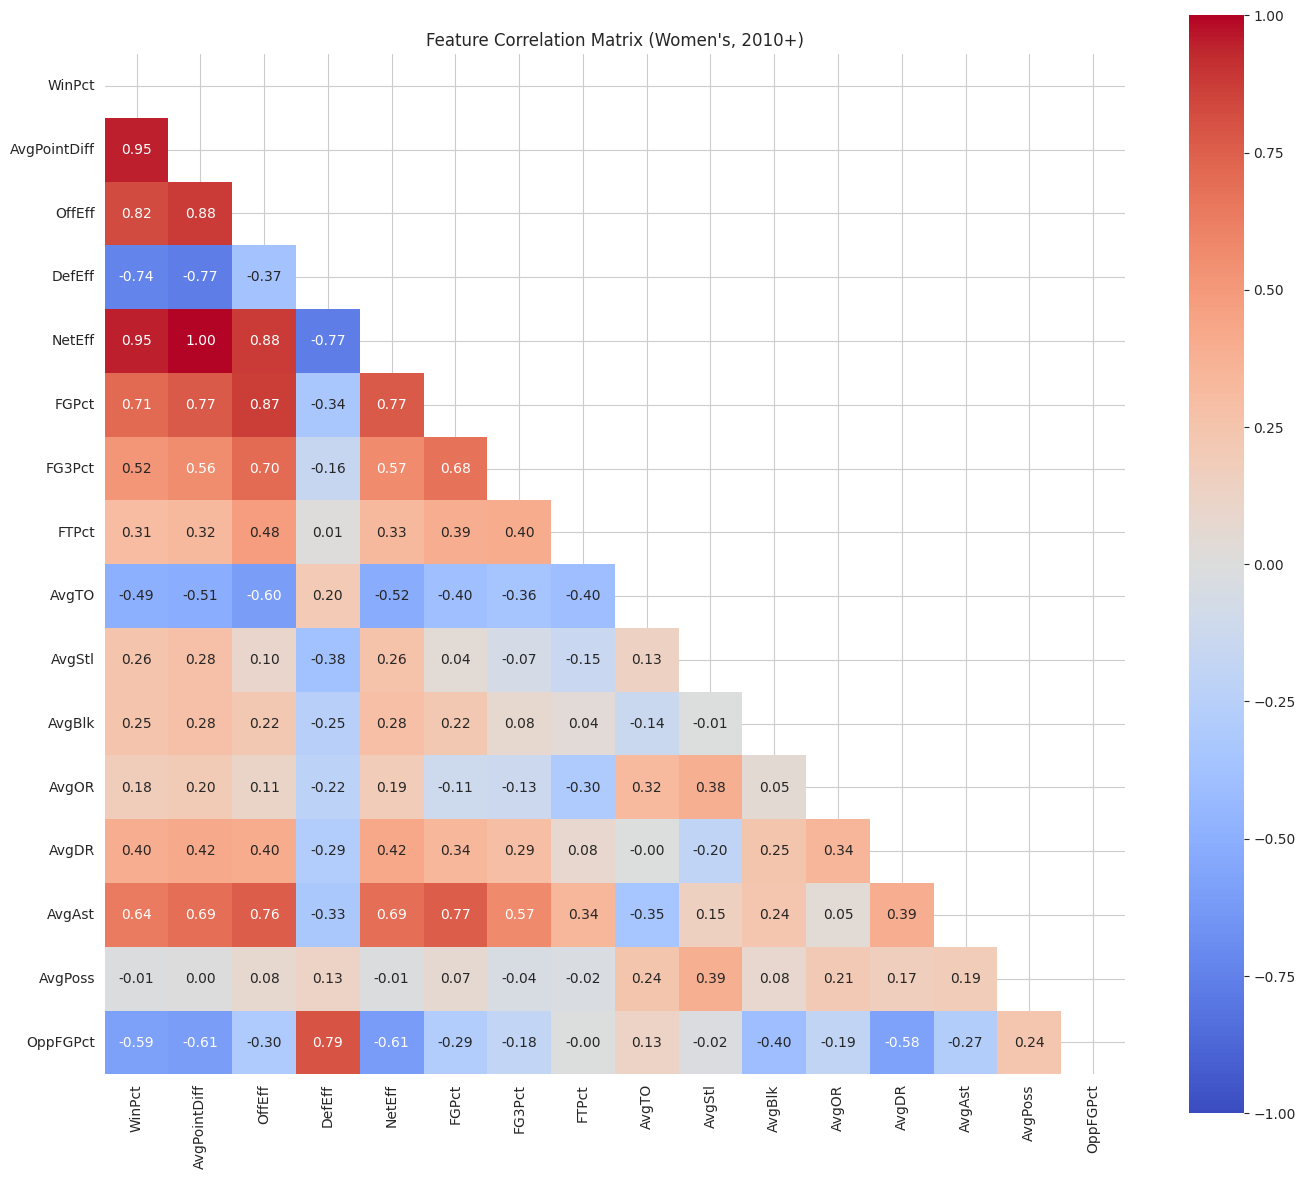


Highly correlated feature pairs (|r| > 0.7):
  WinPct <-> AvgPointDiff: 0.946
  WinPct <-> OffEff: 0.824
  WinPct <-> DefEff: -0.742
  WinPct <-> NetEff: 0.948
  WinPct <-> FGPct: 0.713
  AvgPointDiff <-> OffEff: 0.875
  AvgPointDiff <-> DefEff: -0.767
  AvgPointDiff <-> NetEff: 0.996
  AvgPointDiff <-> FGPct: 0.768
  OffEff <-> NetEff: 0.879
  OffEff <-> FGPct: 0.870
  OffEff <-> FG3Pct: 0.703
  OffEff <-> AvgAst: 0.760
  DefEff <-> NetEff: -0.769
  DefEff <-> OppFGPct: 0.790
  NetEff <-> FGPct: 0.772
  FGPct <-> AvgAst: 0.765


In [17]:
corr_features = ['WinPct', 'AvgPointDiff', 'OffEff', 'DefEff', 'NetEff',
                  'FGPct', 'FG3Pct', 'FTPct', 'AvgTO', 'AvgStl', 'AvgBlk',
                  'AvgOR', 'AvgDR', 'AvgAst', 'AvgPoss', 'OppFGPct']

# Only use columns that exist in the data
corr_features = [c for c in corr_features if c in stats_detail.columns]

corr_matrix = stats_detail[corr_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix (Women\'s, 2010+)')
plt.tight_layout()
save_plot(fig, 'womens_feature_correlation_matrix')
plt.show()

# Flag highly correlated pairs
print("\nHighly correlated feature pairs (|r| > 0.7):")
for i in range(len(corr_features)):
    for j in range(i+1, len(corr_features)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {corr_features[i]} <-> {corr_features[j]}: {r:.3f}")

## 8. Key Takeaways

Summary of EDA findings to inform downstream feature engineering and modeling.

In [18]:
print("""
EDA KEY TAKEAWAYS — WOMEN'S
===========================

1. SEEDS: Even more predictive than men's. The women's tournament has
   historically fewer upsets — higher seeds dominate more consistently.
   Seed difference is the single most important feature.

2. NO MASSEY ORDINALS: Unlike men's, there are no Massey Ordinal rankings
   available for women's. This means we must rely more heavily on seeds,
   win percentage, and box score statistics. This is a significant data
   disadvantage compared to the men's pipeline.

3. SHORTER DETAILED HISTORY: Detailed box scores only go back to 2010
   (vs 2003 for men's), so we have fewer seasons of detailed stats.
   ~1.5% of games in 2010-2012 may have missing detailed results.

4. DISCRIMINATING FEATURES: NetEff, WinPct, AvgPointDiff are the strongest
   separators between tournament and non-tournament teams, similar to men's.
   Defensive stats (DefEff, OppFGPct) remain important.

5. TOURNAMENT WIN CORRELATES: SeedNum (negative — lower seed = more wins),
   NetEff, WinPct, and AvgPointDiff correlate most with tournament wins.
   The dominance of seeds may be even stronger for women's.

6. MULTICOLLINEARITY: Similar patterns to men's — WinPct, AvgPointDiff, and
   NetEff are highly correlated. Use difference features and consider
   feature selection to reduce redundancy.

7. SIMPLER MODELS MAY WORK: With fewer upsets and no Massey data, the
   women's tournament may be more predictable with simpler models.
   Seed-based features carry even more weight. Over-engineering features
   may hurt rather than help.

8. POWER CONFERENCES: Power conference teams get better seeds and win more
   tournament games on average. IsPowerConf may add marginal value but is
   largely captured by seed.

RECOMMENDED FEATURE PRIORITY (Women's):
  1. Seed difference (most important — even more so than men's)
  2. NetEff difference (offensive - defensive efficiency)
  3. WinPct difference
  4. Defensive efficiency difference
  5. Shooting efficiency differences (FGPct, FG3Pct)
  6. Turnover and rebounding differences
  7. Conference strength indicators

NOTE: Without Massey Ordinals, the feature set is smaller than men's.
Consider whether external ranking data could be sourced to compensate.
""")


EDA KEY TAKEAWAYS — WOMEN'S

1. SEEDS: Even more predictive than men's. The women's tournament has
   historically fewer upsets — higher seeds dominate more consistently.
   Seed difference is the single most important feature.

2. NO MASSEY ORDINALS: Unlike men's, there are no Massey Ordinal rankings
   available for women's. This means we must rely more heavily on seeds,
   win percentage, and box score statistics. This is a significant data
   disadvantage compared to the men's pipeline.

3. SHORTER DETAILED HISTORY: Detailed box scores only go back to 2010
   (vs 2003 for men's), so we have fewer seasons of detailed stats.
   ~1.5% of games in 2010-2012 may have missing detailed results.

4. DISCRIMINATING FEATURES: NetEff, WinPct, AvgPointDiff are the strongest
   separators between tournament and non-tournament teams, similar to men's.
   Defensive stats (DefEff, OppFGPct) remain important.

5. TOURNAMENT WIN CORRELATES: SeedNum (negative — lower seed = more wins),
   NetEff, Wi